In [4]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [5]:
!pip install -q kagglehub

In [6]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "gunavenkatdoddi/eye-diseases-classification"
)

print("Dataset path:", dataset_path)

100%|██████████| 736M/736M [00:07<00:00, 110MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/gunavenkatdoddi/eye-diseases-classification/versions/1


In [7]:
import os

print(os.listdir(dataset_path))

['dataset']


In [8]:
data_dir = os.path.join(dataset_path, "dataset")

print("Dataset folder:", data_dir)
print("Classes:", os.listdir(data_dir))

Dataset folder: /root/.cache/kagglehub/datasets/gunavenkatdoddi/eye-diseases-classification/versions/1/dataset
Classes: ['diabetic_retinopathy', 'cataract', 'glaucoma', 'normal']


In [9]:
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        print(class_name, ":", len(os.listdir(class_path)), "images")

diabetic_retinopathy : 1098 images
cataract : 1038 images
glaucoma : 1007 images
normal : 1074 images


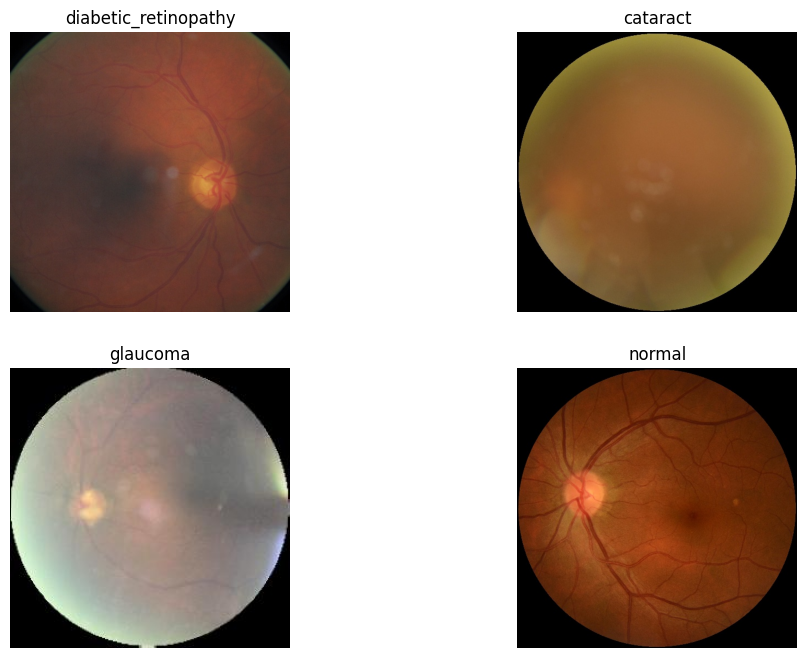

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(data_dir)

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(data_dir, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [11]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

weights = ConvNeXt_Tiny_Weights.DEFAULT

model = convnext_tiny(weights=weights)

In [12]:
import os
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Seed:", SEED)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
Seed: 42
GPU: Tesla T4


Load the dataset to pythoch

In [13]:
from torchvision import datasets

full_dataset = datasets.ImageFolder(root=data_dir)

print("Total images:", len(full_dataset))
print("Classes:", full_dataset.classes)
print("Class mapping:", full_dataset.class_to_idx)

Total images: 4217
Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Class mapping: {'cataract': 0, 'diabetic_retinopathy': 1, 'glaucoma': 2, 'normal': 3}


Train / Validation / Test split

In [14]:
from sklearn.model_selection import train_test_split
import numpy as np

targets = np.array(full_dataset.targets)
indices = np.arange(len(full_dataset))

# First: 70% train, 30% temporary
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=targets,
    random_state=SEED
)

# Second: temporary 30% -> 15% validation + 15% test
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=targets[temp_idx],
    random_state=SEED
)

print("Total:", len(indices))
print("Training:", len(train_idx))
print("Validation:", len(val_idx))
print("Testing:", len(test_idx))

print("\nPercentages:")
print(f"Train: {len(train_idx)/len(indices)*100:.2f}%")
print(f"Validation: {len(val_idx)/len(indices)*100:.2f}%")
print(f"Test: {len(test_idx)/len(indices)*100:.2f}%")

Total: 4217
Training: 2951
Validation: 633
Testing: 633

Percentages:
Train: 69.98%
Validation: 15.01%
Test: 15.01%


Class distribution verify

,Class,Total,Train,Validation,Test
0,cataract,1038,726,156,156
1,diabetic_retinopathy,1098,768,165,165
2,glaucoma,1007,705,151,151
3,normal,1074,752,161,161


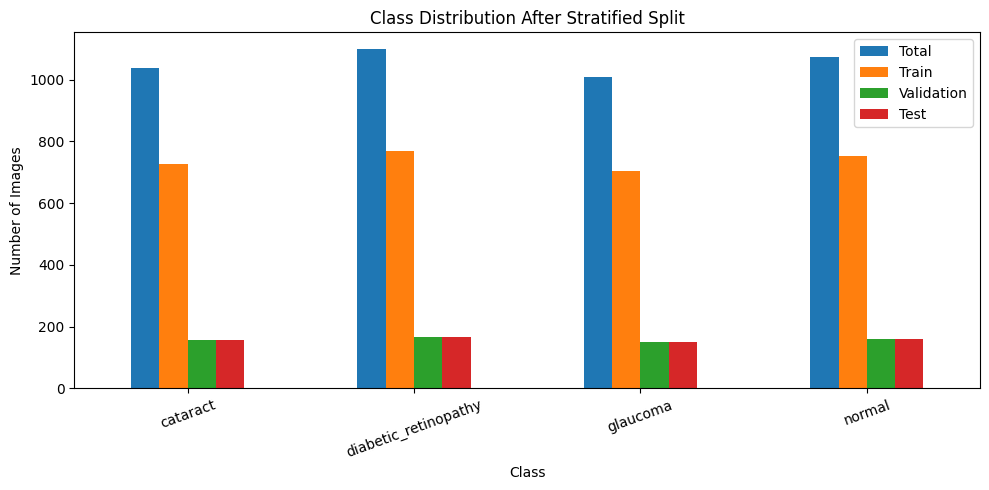

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

class_names = full_dataset.classes

distribution = []

for i, class_name in enumerate(class_names):
    distribution.append({
        "Class": class_name,
        "Total": np.sum(targets == i),
        "Train": np.sum(targets[train_idx] == i),
        "Validation": np.sum(targets[val_idx] == i),
        "Test": np.sum(targets[test_idx] == i)
    })

distribution_df = pd.DataFrame(distribution)

display(distribution_df)

distribution_df.set_index("Class").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Class Distribution After Stratified Split")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

ConvNeXt preprocessing

In [16]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Separate datasets create

In [17]:
from torch.utils.data import Subset

train_base = datasets.ImageFolder(
    root=data_dir,
    transform=train_transform
)

eval_base = datasets.ImageFolder(
    root=data_dir,
    transform=val_test_transform
)

train_dataset = Subset(train_base, train_idx)
val_dataset = Subset(eval_base, val_idx)
test_dataset = Subset(eval_base, test_idx)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 2951
Validation: 633
Test: 633


DataLoader

In [18]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 93
Validation batches: 20
Test batches: 20


DataLoader එක test කරමු

In [19]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: tensor([1, 1, 3, 0, 3, 3, 1, 3, 2, 0])


ConvNeXt-Tiny model එක properly configure කරමු

In [20]:
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

weights = ConvNeXt_Tiny_Weights.DEFAULT

model = convnext_tiny(weights=weights)

print(model.classifier)

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=1000, bias=True)
)


Classification layer එක 4 classes වලට වෙනස් කරමු

In [21]:
num_classes = len(class_names)

in_features = model.classifier[2].in_features

model.classifier[2] = nn.Linear(
    in_features,
    num_classes
)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=4, bias=True)
)


Model parameters බලමු

In [22]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 27,823,204
Trainable parameters: 27,823,204


Loss Function + Optimizer

In [23]:
criterion = nn.CrossEntropyLoss()

In [24]:
import torch.optim as optim

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Loss Function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning Rate:", LEARNING_RATE)
print("Weight Decay:", WEIGHT_DECAY)

Loss Function: CrossEntropyLoss()
Optimizer: AdamW
Learning Rate: 0.0001
Weight Decay: 0.0001


Learning-rate scheduler එකක් add කරමු

In [25]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

Training history variables

In [26]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")

Training + Validation function

In [27]:
import time

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def validate_one_epoch(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

Model Training

In [28]:
EPOCHS = 15

In [29]:
EPOCHS = 15

training_start_time = time.time()

for epoch in range(EPOCHS):

    epoch_start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Update learning rate
    scheduler.step(val_loss)

    # Save best model based ONLY on validation loss
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "/content/best_convnext_tiny.pth"
        )

        saved = " <-- Best model saved"

    else:
        saved = ""

    epoch_time = time.time() - epoch_start_time

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"Time: {epoch_time:.1f}s"
        f"{saved}"
    )

total_training_time = time.time() - training_start_time

print("\nTraining completed.")
print(f"Total training time: {total_training_time/60:.2f} minutes")

Epoch [1/15] | Train Loss: 0.5332 | Train Acc: 78.58% | Val Loss: 0.4505 | Val Acc: 86.41% | Time: 66.8s <-- Best model saved
Epoch [2/15] | Train Loss: 0.2460 | Train Acc: 91.73% | Val Loss: 0.3463 | Val Acc: 89.42% | Time: 58.3s <-- Best model saved
Epoch [3/15] | Train Loss: 0.1939 | Train Acc: 93.56% | Val Loss: 0.5051 | Val Acc: 87.99% | Time: 58.9s
Epoch [4/15] | Train Loss: 0.1625 | Train Acc: 94.34% | Val Loss: 0.3878 | Val Acc: 88.94% | Time: 63.8s
Epoch [5/15] | Train Loss: 0.1183 | Train Acc: 96.04% | Val Loss: 0.4319 | Val Acc: 86.89% | Time: 60.7s
Epoch [6/15] | Train Loss: 0.0763 | Train Acc: 97.36% | Val Loss: 0.3829 | Val Acc: 89.57% | Time: 68.7s
Epoch [7/15] | Train Loss: 0.0476 | Train Acc: 98.51% | Val Loss: 0.4505 | Val Acc: 88.63% | Time: 64.4s
Epoch [8/15] | Train Loss: 0.0460 | Train Acc: 98.61% | Val Loss: 0.3651 | Val Acc: 89.89% | Time: 69.9s
Epoch [9/15] | Train Loss: 0.0325 | Train Acc: 98.95% | Val Loss: 0.4313 | Val Acc: 90.52% | Time: 61.6s
Epoch [10/15]

Training results graphs

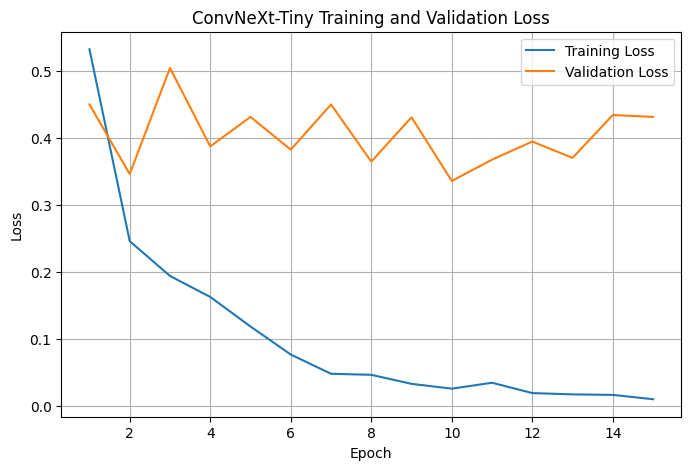

In [30]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ConvNeXt-Tiny Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

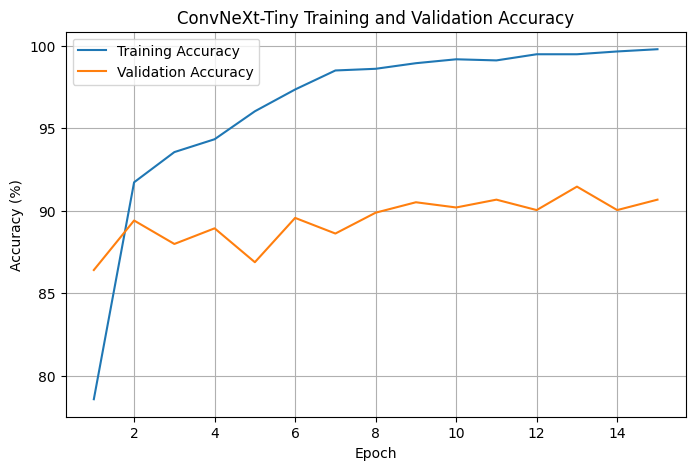

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    [x * 100 for x in train_accuracies],
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    [x * 100 for x in val_accuracies],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ConvNeXt-Tiny Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

Best model නැවත load කරමු

In [32]:
model.load_state_dict(
    torch.load(
        "/content/best_convnext_tiny.pth",
        map_location=device
    )
)

model.eval()

print("Best ConvNeXt-Tiny model loaded.")

Best ConvNeXt-Tiny model loaded.


දැන් පළමු වතාවට Test Set evaluate කරමු

In [33]:
all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)

        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

print("Test predictions completed.")

Test predictions completed.


Accuracy / Precision / Recall / F1

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")

Test Accuracy : 88.94%
Precision     : 0.8918
Recall        : 0.8894
F1 Score      : 0.8880


Detailed Classification Report

In [35]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

                      precision    recall  f1-score   support

            cataract     0.9580    0.8782    0.9164       156
diabetic_retinopathy     0.8639    1.0000    0.9270       165
            glaucoma     0.8797    0.7748    0.8239       151
              normal     0.8675    0.8944    0.8807       161

            accuracy                         0.8894       633
           macro avg     0.8923    0.8869    0.8870       633
        weighted avg     0.8918    0.8894    0.8880       633



Confusion Matrix

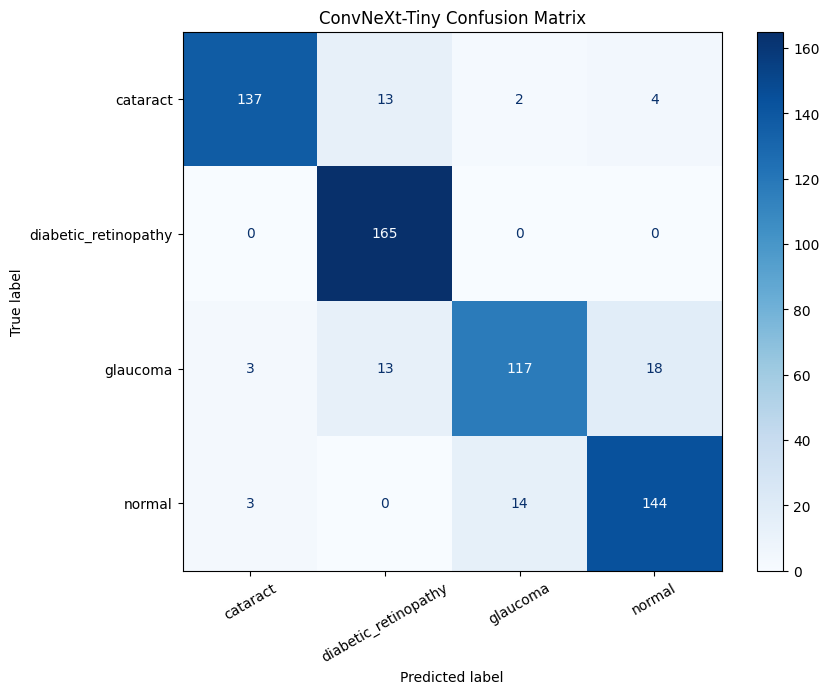

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=30
)

plt.title("ConvNeXt-Tiny Confusion Matrix")
plt.show()

. ROC-AUC calculate කරමු

In [37]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(
    all_labels,
    classes=np.arange(len(class_names))
)

roc_auc = roc_auc_score(
    y_true_bin,
    all_probabilities,
    multi_class="ovr",
    average="weighted"
)

print(f"Weighted ROC-AUC: {roc_auc:.4f}")

Weighted ROC-AUC: 0.9847


ROC curves draw කරමු

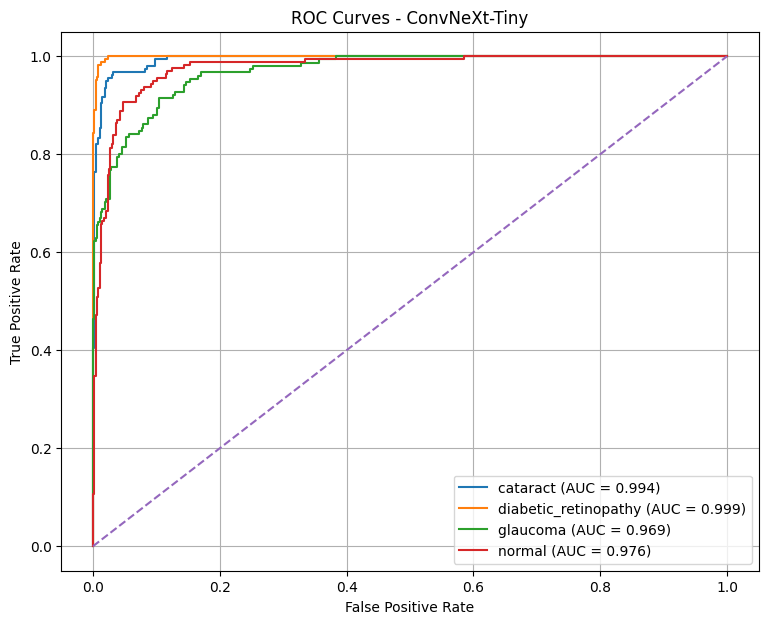

In [38]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 7))

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        all_probabilities[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves - ConvNeXt-Tiny"
)

plt.legend()
plt.grid()
plt.show()

Wrong predictions බලමු

In [39]:
wrong_indices = np.where(
    all_labels != all_predictions
)[0]

print(
    "Number of misclassified test images:",
    len(wrong_indices)
)

Number of misclassified test images: 70


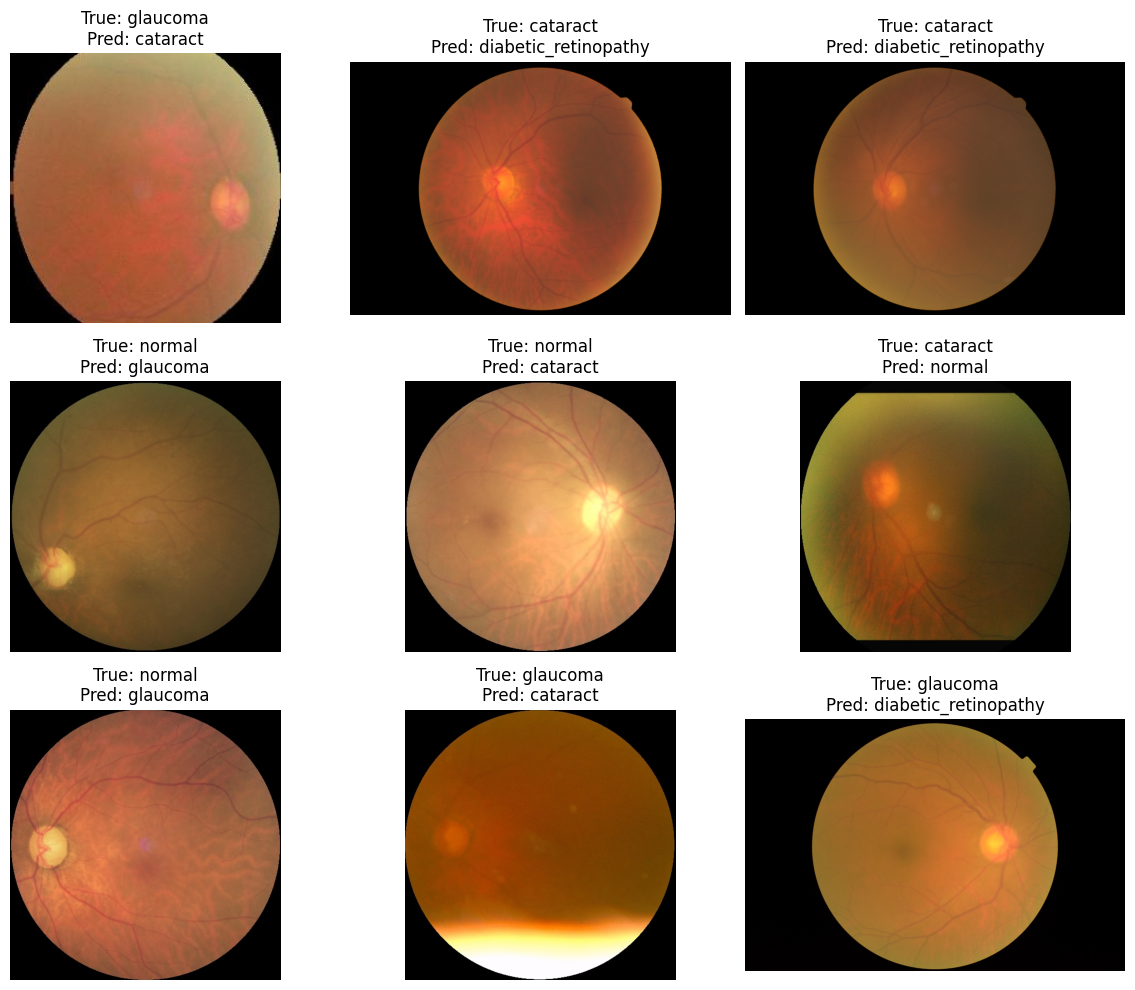

In [40]:
plt.figure(figsize=(12, 10))

num_examples = min(9, len(wrong_indices))

for plot_i in range(num_examples):

    prediction_position = wrong_indices[plot_i]

    dataset_index = test_idx[prediction_position]

    image_path, true_label = eval_base.samples[dataset_index]

    image = Image.open(image_path).convert("RGB")

    predicted_label = all_predictions[prediction_position]

    plt.subplot(3, 3, plot_i + 1)

    plt.imshow(image)

    plt.title(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[predicted_label]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Correct predictionsත් බලමු

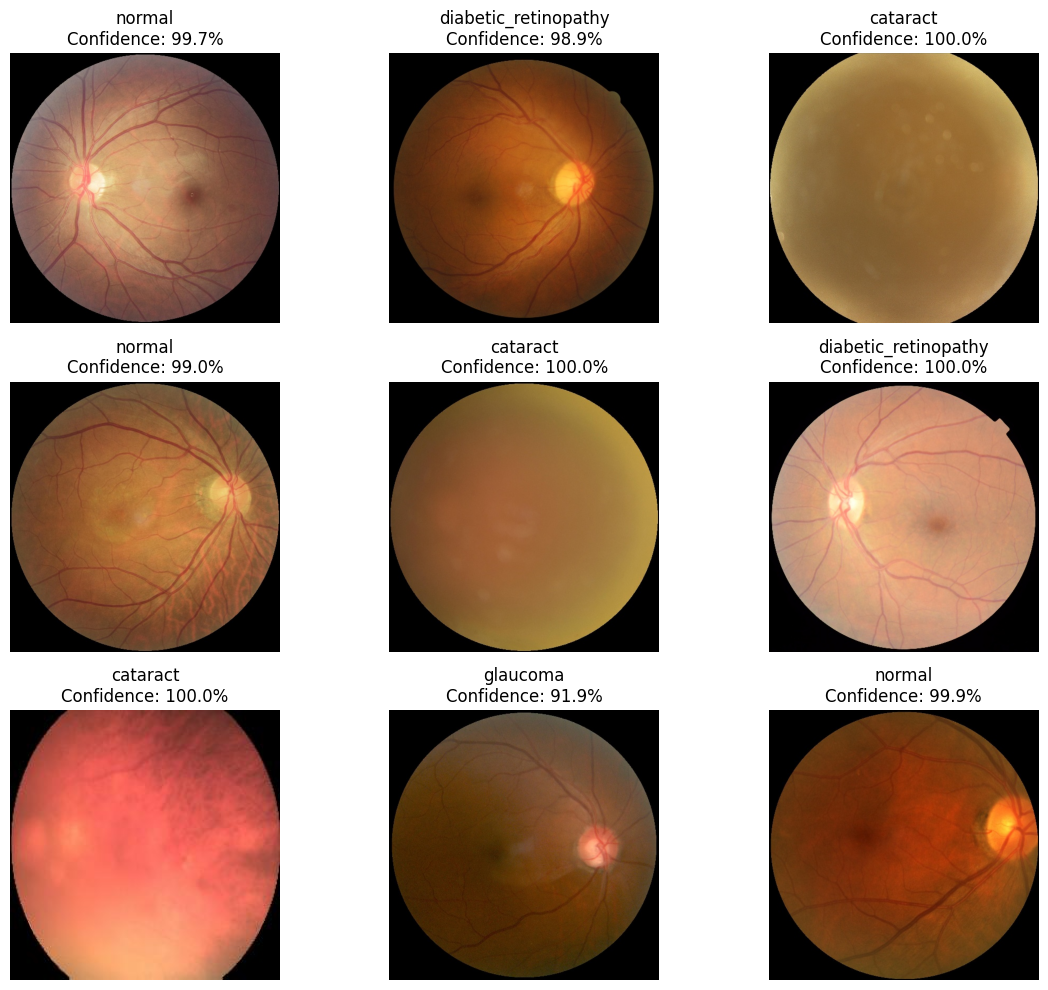

In [41]:
correct_indices = np.where(
    all_labels == all_predictions
)[0]

plt.figure(figsize=(12, 10))

num_examples = min(9, len(correct_indices))

for plot_i in range(num_examples):

    prediction_position = correct_indices[plot_i]

    dataset_index = test_idx[prediction_position]

    image_path, true_label = eval_base.samples[dataset_index]

    image = Image.open(image_path).convert("RGB")

    confidence = np.max(
        all_probabilities[prediction_position]
    )

    plt.subplot(3, 3, plot_i + 1)

    plt.imshow(image)

    plt.title(
        f"{class_names[true_label]}\n"
        f"Confidence: {confidence*100:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Final results summary හදමු

In [42]:
results = {
    "Model": "ConvNeXt-Tiny",
    "Dataset": "Eye Diseases Classification",
    "Number of Classes": len(class_names),
    "Total Images": len(full_dataset),
    "Train Images": len(train_dataset),
    "Validation Images": len(val_dataset),
    "Test Images": len(test_dataset),
    "Input Size": "224x224",
    "Batch Size": BATCH_SIZE,
    "Epochs": EPOCHS,
    "Learning Rate": LEARNING_RATE,
    "Optimizer": "AdamW",
    "Loss Function": "CrossEntropyLoss",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc,
    "Total Parameters": total_params,
    "Training Time (minutes)": total_training_time / 60
}

results_df = pd.DataFrame(
    [results]
)

display(results_df)

,Model,Dataset,Number of Classes,Total Images,Train Images,Validation Images,Test Images,Input Size,Batch Size,Epochs,Learning Rate,Optimizer,Loss Function,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Total Parameters,Training Time (minutes)
0,ConvNeXt-Tiny,Eye Diseases Classification,4,4217,2951,633,633,224x224,32,15,0.0001,AdamW,CrossEntropyLoss,0.889415,0.891771,0.889415,0.888025,0.984655,27823204,15.035301


CSV එකක් save කරමු

In [43]:
results_df.to_csv(
    "/content/convnext_tiny_results.csv",
    index=False
)

print("Results saved.")

Results saved.


Model එක Google Drive එකට save කරන්න

In [44]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [45]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc
    },
    "/content/drive/MyDrive/convnext_tiny_eye_disease.pth"
)

print("Model saved to Google Drive.")

Model saved to Google Drive.


Experiment configuration save කරමු

In [46]:
config = {
    "seed": SEED,
    "model": "ConvNeXt-Tiny",
    "pretrained_weights": "ImageNet",
    "image_size": 224,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "optimizer": "AdamW",
    "loss": "CrossEntropyLoss",
    "train_split": 0.70,
    "validation_split": 0.15,
    "test_split": 0.15
}

print(config)

{'seed': 42, 'model': 'ConvNeXt-Tiny', 'pretrained_weights': 'ImageNet', 'image_size': 224, 'batch_size': 32, 'epochs': 15, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'optimizer': 'AdamW', 'loss': 'CrossEntropyLoss', 'train_split': 0.7, 'validation_split': 0.15, 'test_split': 0.15}
